In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("digital_marketing_campiagn_dataset.csv")

df.head()
df.info()
df.describe(include="all")
df['Conversion'].value_counts(normalize=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

,proportion
Conversion,
1,0.8765
0,0.1235


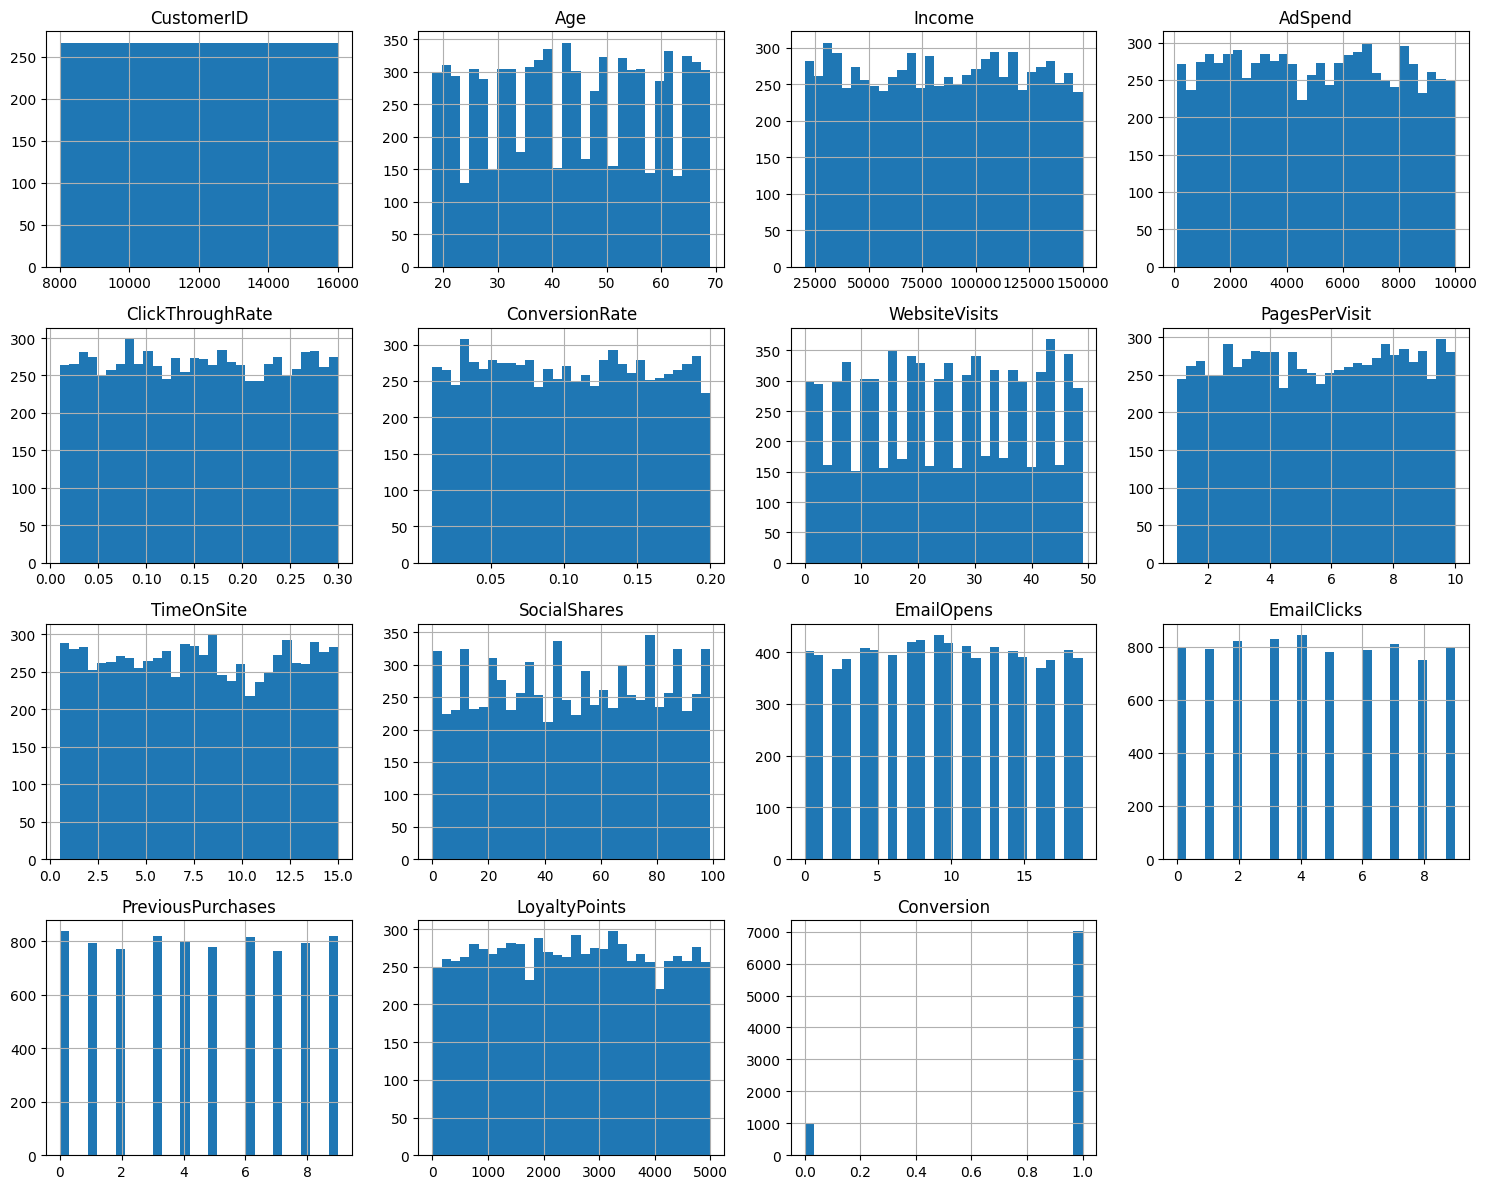

In [ ]:
df.hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()


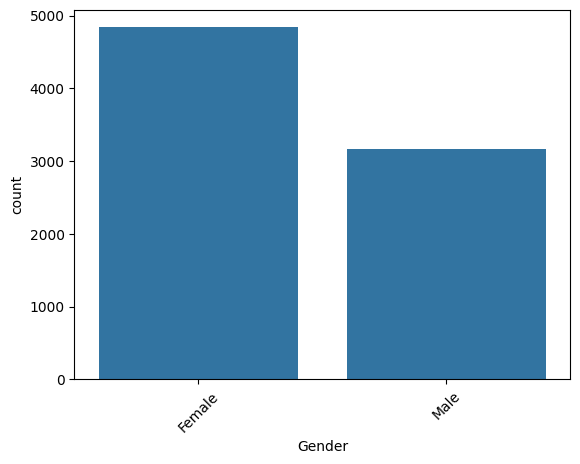

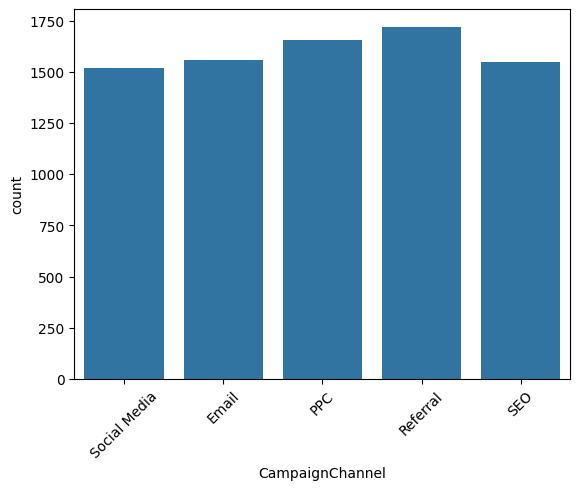

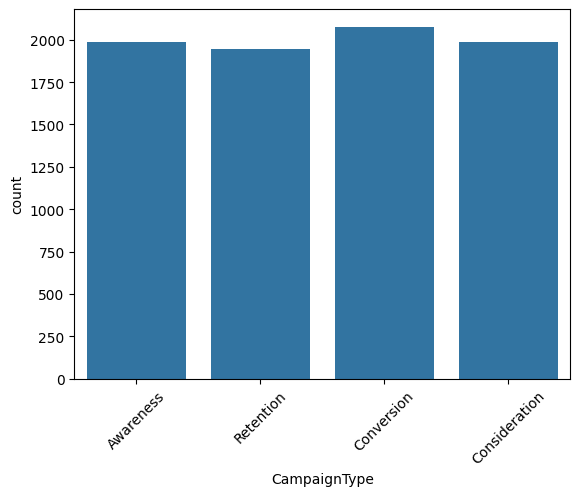

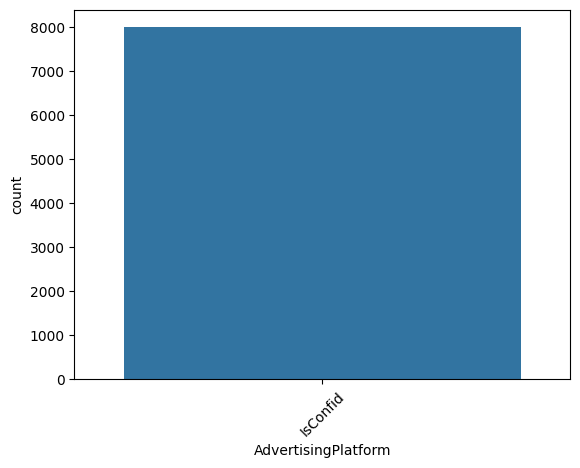

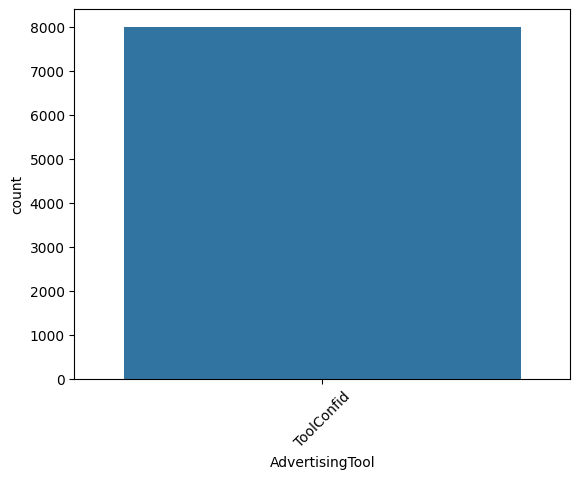

In [ ]:
categorical_cols = ['Gender','CampaignChannel','CampaignType',
                    'AdvertisingPlatform','AdvertisingTool']

for col in categorical_cols:
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.show()


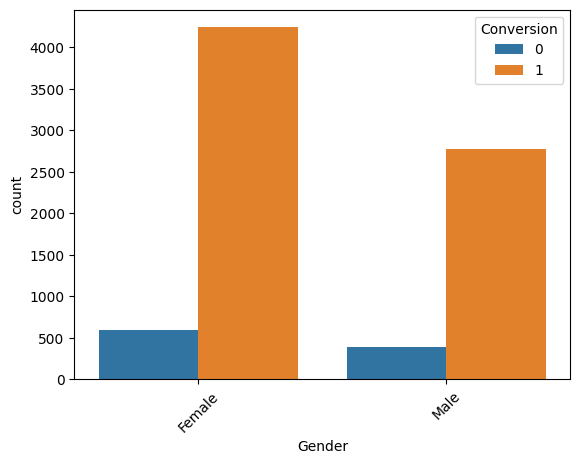

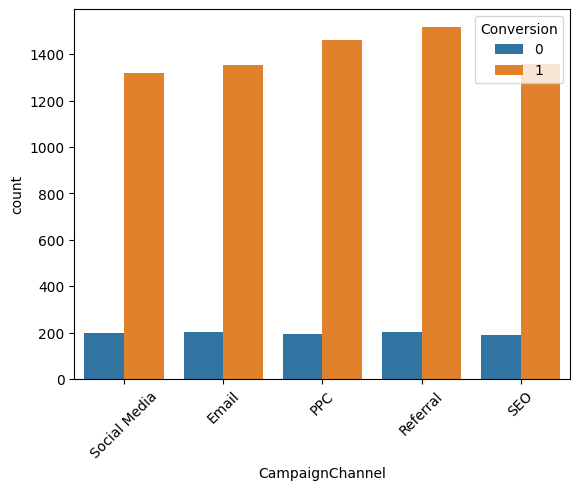

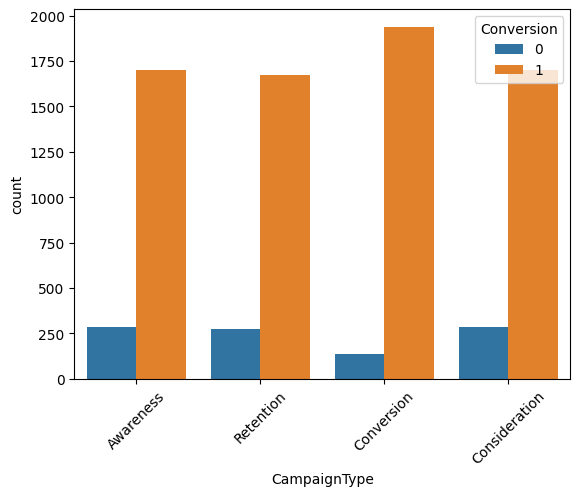

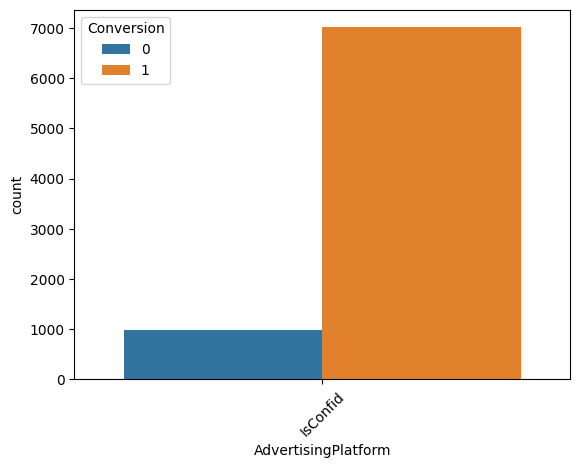

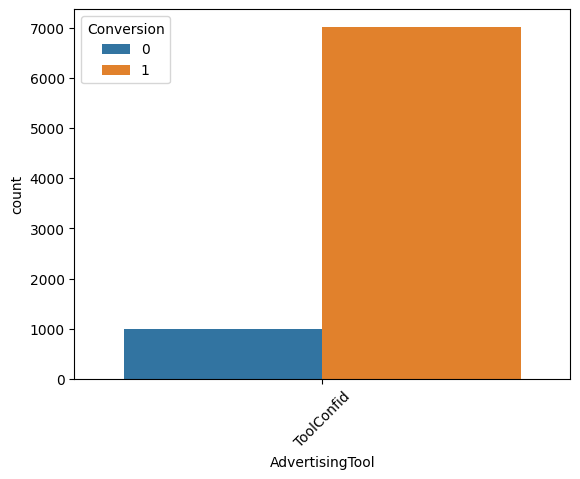

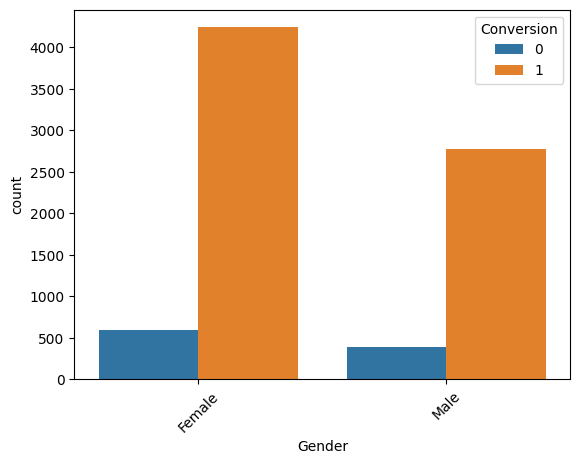

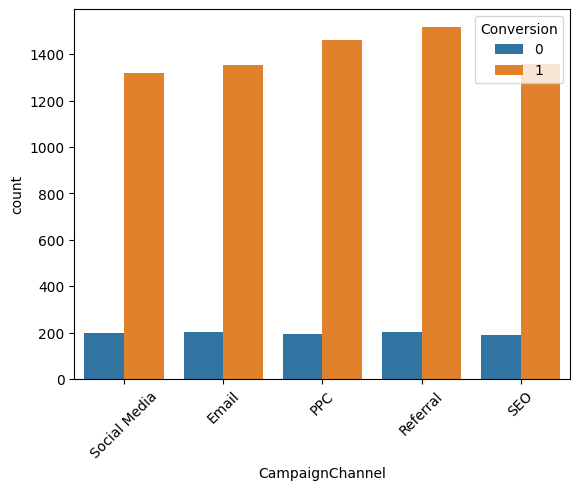

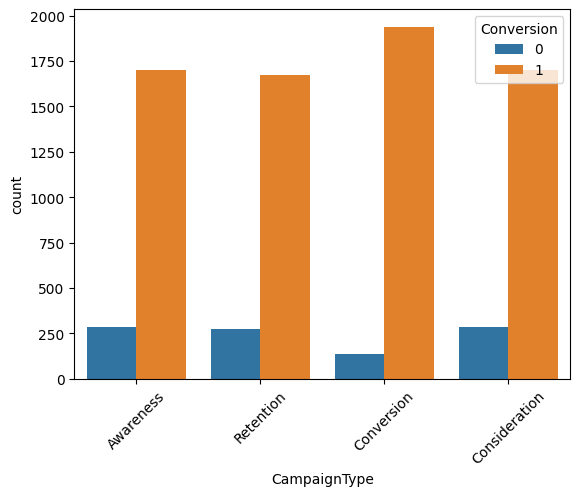

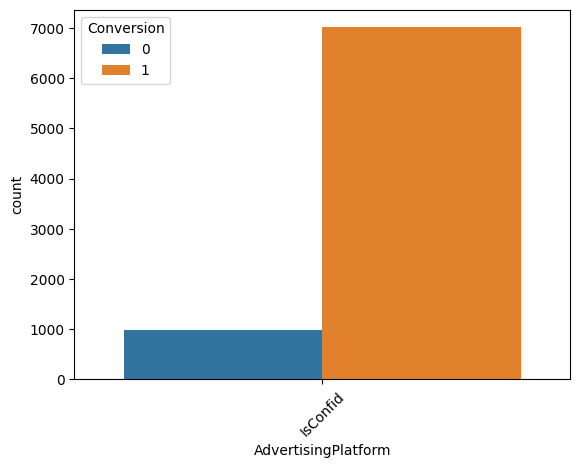

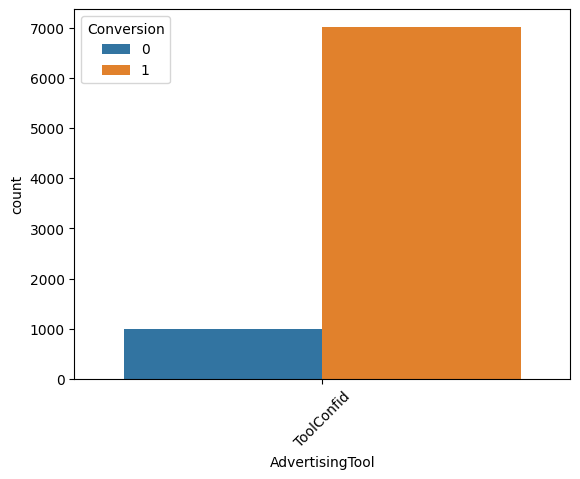

In [ ]:
for col in categorical_cols:
    sns.countplot(data=df, x=col, hue='Conversion')
    plt.xticks(rotation=45)
    plt.show()



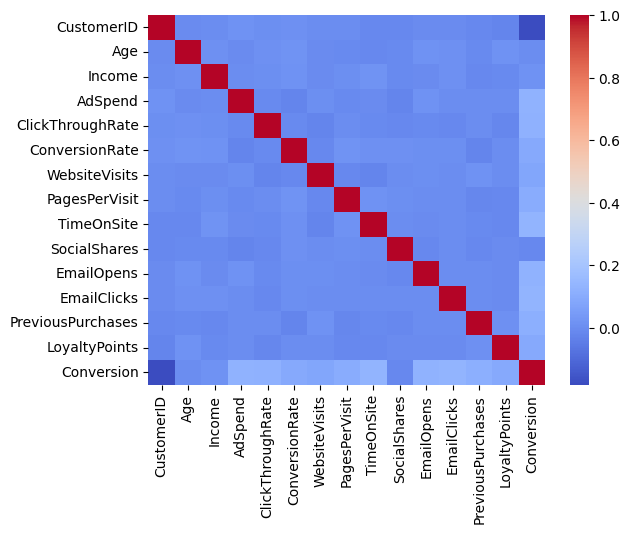

In [ ]:
import numpy as np

numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_cols.remove('Conversion')

corr = df[numeric_cols + ['Conversion']].corr()
sns.heatmap(corr, cmap='coolwarm')
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Conversion', axis=1)
y = df['Conversion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

numeric_features = ['Age','Income','AdSpend','ClickThroughRate','ConversionRate',
                    'WebsiteVisits','PagesPerVisit','TimeOnSite','SocialShares',
                    'EmailOpens','EmailClicks','PreviousPurchases','LoyaltyPoints']

categorical_features = ['Gender','CampaignChannel','CampaignType',
                        'AdvertisingPlatform','AdvertisingTool']

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

log_reg = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

rf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
    ))
])

log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Income', 'AdSpend',
                                                   'ClickThroughRate',
                                                   'ConversionRate',
                                                   'WebsiteVisits',
                                                   'PagesPerVisit',
                                                   'TimeOnSite', 'SocialShares',
                                                   'EmailOpens', 'EmailClicks',
                                                   'PreviousPurchases',
                                                   'LoyaltyPoints']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'CampaignChannel',
                                                   'CampaignType',
                                                   'AdvertisingPlatform',
                                                   'AdvertisingTool'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

log_results = evaluate_model(log_reg, X_test, y_test)
rf_results = evaluate_model(rf, X_test, y_test)

log_results, rf_results


({'Accuracy': 0.7525,
  'Precision': 0.9523381294964028,
  'Recall': 0.7553495007132668,
  'F1 Score': 0.8424821002386634,
  'ROC-AUC': np.float64(0.7815350365279038)},
 {'Accuracy': 0.88375,
  'Precision': 0.8843236409608091,
  'Recall': 0.9978601997146933,
  'F1 Score': 0.9376675603217158,
  'ROC-AUC': np.float64(0.8160384155391287)})

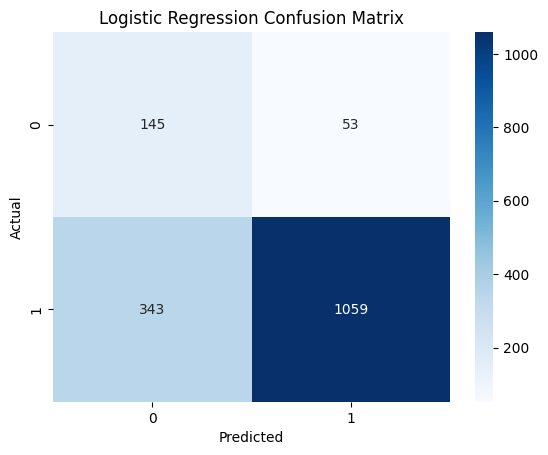

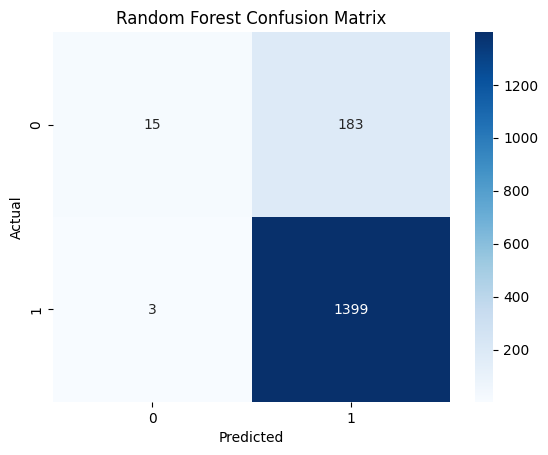

In [ ]:
from sklearn.metrics import confusion_matrix

def plot_cm(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(log_reg, X_test, y_test, "Logistic Regression Confusion Matrix")
plot_cm(rf, X_test, y_test, "Random Forest Confusion Matrix")


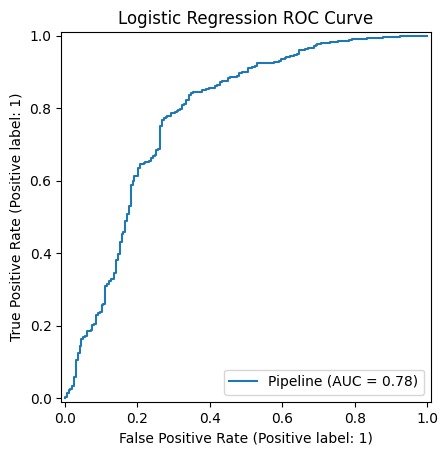

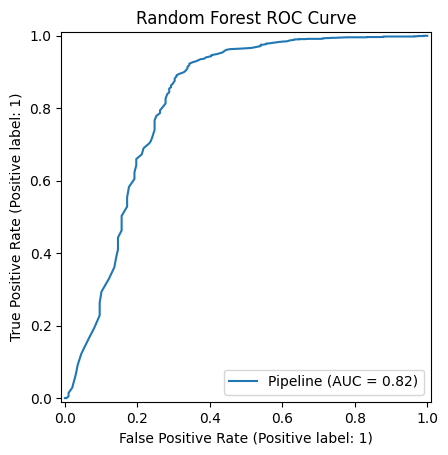

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(log_reg, X_test, y_test)
plt.title("Logistic Regression ROC Curve")
plt.show()

RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest ROC Curve")
plt.show()


In [ ]:
# Extract OneHotEncoder
ohe = log_reg.named_steps['preprocess'].named_transformers_['cat']

# Get encoded categorical names
cat_feature_names = ohe.get_feature_names_out(categorical_features)

# Combine numeric + categorical names
all_feature_names = numeric_features + list(cat_feature_names)

# Extract coefficients
lr_model = log_reg.named_steps['model']
coeffs = lr_model.coef_[0]

# Build DataFrame
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coeffs
})

# Sort by absolute value
coef_df = coef_df.reindex(coef_df.Coefficient.abs().sort_values(ascending=False).index)

coef_df.head(20)


,Feature,Coefficient
22,CampaignType_Conversion,0.569014
3,ClickThroughRate,0.450015
7,TimeOnSite,0.436654
10,EmailClicks,0.415227
2,AdSpend,0.384396
9,EmailOpens,0.380872
12,LoyaltyPoints,0.364646
11,PreviousPurchases,0.361580
6,PagesPerVisit,0.293579
4,ConversionRate,0.265428


In [ ]:
# Extract OneHotEncoder
ohe = rf.named_steps['preprocess'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(cat_feature_names)

rf_model = rf.named_steps['model']
importances = rf_model.feature_importances_

rf_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

rf_importance_df.head(20)


,Feature,Importance
7,TimeOnSite,0.093197
3,ClickThroughRate,0.090900
6,PagesPerVisit,0.089712
2,AdSpend,0.089539
12,LoyaltyPoints,0.077279
4,ConversionRate,0.075946
11,PreviousPurchases,0.067591
9,EmailOpens,0.061582
5,WebsiteVisits,0.060648
10,EmailClicks,0.057722


/tmp/ipykernel_19931/2954179730.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


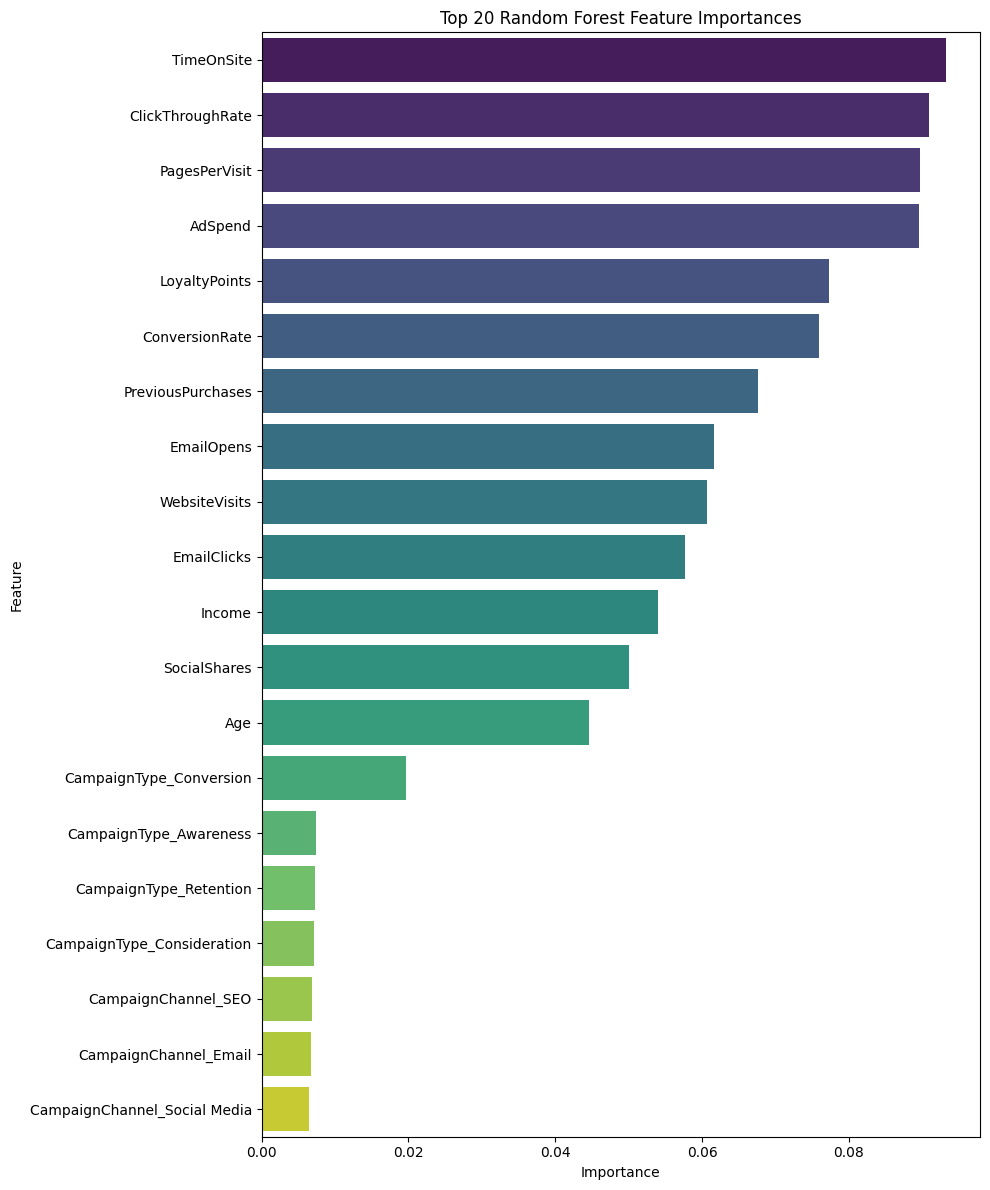

In [ ]:
plt.figure(figsize=(10, 12))
sns.barplot(
    data=rf_importance_df.head(20),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title("Top 20 Random Forest Feature Importances")
plt.tight_layout()
plt.show()
